In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Ground Truth Sentences
merged_ground_truth_sentences = [
    "great god gives life to people city",
    "the god / deity gives life (ankh) people",
    "father and mother give life child",
    "king sits upon throne great power",
    "man eats bread drinks water peacefully",
    "woman gives birth life continues forever",
    "god emerges from horizon bringing light",
    "people love peace content satisfied life",
    "lord of town holds authority power",
    "old man hears wisdom of god",
    "scribe writes book in temple quietly",
    "river flows beside city bringing life",
    "farmer plows field grows grain food",
    "god sees heart of every man",
    "soul (ba) rises to sky star",
    "scarab becomes life symbol of rebirth",
    "house opens door welcomes people inside",
    "fire gives warmth to family home",
    "man walks road toward city gate",
    "king wears crown symbol of authority",
    "mother loves child with gentle heart",
    "god protects people with great strength",
    "offering placed upon altar for god",
    "riverbank holds reeds near flowing water",
    "temple stands strong upon stone foundation",
    "heart listens and understands truth maat",
    "star shines above desert hill night",
    "life emerges from water and earth",
    "people gather inside town at dawn",
    "king hears people and gives justice",
    "god grants power and stability djed",
    "man fears storm and seeks shelter",
    "scribe learns writing through long study",
    "people cross river to reach town",
    "life continues after death in west",
    "god guides soul through dark underground",
    "child grows strong with food milk",
    "people praise god with joyful voice",
    "king builds temple for great god",
    "peace fills house when hearts align",
    "great god / deity gives birth life people",
    "seated king holds power authority throne",
    "father mother give life youth",
    "god emerges horizon sky light",
    "people cross river reach town",
    "scribe writing / scribe book temple",
    "man eat / drink / speak loaf of bread",
    "woman love life peace / content (satisfied)",
    "soul (ba) rise sky star",
    "scarab / become life (ankh) symbol rebirth",
    "king hear / listen people give justice",
    "offering peace / altar god temple",
    "river water ripple life field",
    "plows (tills) field grain / pellet life",
    "old man heart wisdom god",
    "god sees heart man truth",
    "life opens / exists (or is found) underground west",
    "people fear storm seek house",
    "temple stone strong stability (djed)",
    "mother gives birth / begets child life",
    "road leads city / town gate",
    "fire strength / force life house",
    "god protects people great / mighty power",
    "riverbank reed leaf papyrus clump water",
    "king builds seat / throne authority power",
    "peace / satisfy heart people life",
    "life continues west soul (ba)",
    "man walks road toward horizon",
    "god grants life thousand years",
    "house opens / exists (or is found) gate people",
    "great / big god / deity power authority throne",
    "seated man heart love peace / content (satisfied)",
    "woman gives birth / begets life youth people",
    "father mother life (ankh) love heart",
    "king sedge (king) power great / mighty throne",
    "scribe writing / scribe papyrus scroll book",
    "people fear storm fire strength / force",
    "river water ripple field grain / pellet",
    "plows (repeated) field life food offering",
    "temple stone stability (djed) great",
    "soul (ba) sky star horizon",
    "scarab / become life (ankh) heart",
    "god sees eye truth feather (truth/maat)",
    "house gate door bolt opens / exists (or is found)",
    "road city / town gate people",
    "old man wisdom heart hear / listen",
    "riverbank reed leaf papyrus clump lake",
    "west underground soul (ba) life",
    "god / deity great / mighty power strength / force stability (djed)",
    "seated god / king throne authority power great",
    "people love life peace / satisfy heart",
    "mother milk jar child life love",
    "father backbone strength / force life authority",
    "king hears people speaks justice power",
    "scribe papyrus scroll writing / scribe book",
    "river lake water ripple life field",
    "plows (tills) field grain / pellet offering",
    "temple pillar / grandfather stone stability (djed)",
    "soul (ba) emerges horizon sky light",
    "scarab / become to become life (ankh) rebirth",
    "house reed shelter peace / content (satisfied) life",
    "road riverbank town gate people",
    "god sees eye heart truth",
    "old man venerated / marrow wisdom heart",
    "west underground soul (ba) afterlife life",
    "offering loaf of bread peace / altar god",
    "fire storm fear strength / force heart",
    "woman seated woman life love heart",
    "cobra snake fear strength / force fire heart life",
    "owl sky star sees eye god man",
    "horned viper desert hill fear man life god",
    "papyrus clump plant field life water ripple river lake",
    "quail chick youth life people town man",
    "reed shelter house peace / content (satisfied) people life woman man",
    "basket with handle offering loaf of bread god temple peace / altar people",
    "tethering rope coil of rope ring power authority king god",
    "seat / throne stool / mat seated man house peace / content (satisfied) life people",
    "senet board seated man people house peace / content (satisfied) life heart",
    "pillar / grandfather backbone stability (djed) strength / force life god power",
    "head of ox offering peace / altar god temple people life",
    "head of bird sky horizon sees eye god star",
    "milk jar jar vessel life youth woman mother",
    "three fox skins old man venerated / marrow heart life god people",
    "twisted flax rope tethering rope strength / force power king authority",
    "single stroke stroke (plural marker) thousand thing power authority god",
    "writing / scribe seated man papyrus scroll book temple people life",
    "swallow swallow (great) sky star god life power",
    "sedge (king) throne power authority king god great / mighty",
    "above sky star horizon god sees",
    "behind / back house gate road town people",
    "basket (lord / all) offering loaf of bread god temple",
    "brick stone house city / town people life",
    "chisel adze stone temple building power",
    "club strength / force authority king power fear",
    "coil of rope tethering rope ring power authority",
    "conical loaf (give) offering god people life",
    "cross road riverbank town people gate",
    "cut plant field plows (tills) grain / pellet",
    "desert hill horizon west underground soul (ba)",
    "desert hare (to be) fear snake desert life",
    "do to do / make thing power authority",
    "door bolt gate house peace / content (satisfied)",
    "eat / drink / speak mouth heart life people",
    "emerge horizon sky light life god",
    "face / on (upon) throne seated god / king power",
    "father mother placenta life youth people",
    "feather (truth/maat) heart truth god sees",
    "folded cloth seat / throne seated man house",
    "forearm hand strength / force power authority",
    "gives birth / begets mother woman life youth",
    "grain / pellet jar jars in rack offering",
    "great / big mountain hill strength / force power",
    "head of bird swallow sky star horizon",
    "head of ox plows (repeated) field strength / force",
    "hear hear / listen heart people god",
    "hill slope road desert hill travel",
    "hoe plows (tills) field plant grain / pellet",
    "house opens / exists (or is found) life peace / satisfy",
    "above sky star god sees eye heart",
    "behind / back house road town gate people life",
    "brick stone house city / town people life power",
    "chisel adze stone temple power authority god",
    "club strength / force power fear man heart life",
    "coil of rope tethering rope ring power authority king god",
    "cross road river town gate people life",
    "cut plant field plows (tills) grain / pellet life offering",
    "desert hill horizon west underground soul (ba) life",
    "do to do / make thing power authority god king",
    "door bolt gate house peace / satisfy heart life people",
    "eat / drink / speak mouth heart people life god man",
    "emerge horizon sky life god soul (ba) star",
    "face / upon throne seated god / king power authority great / mighty stability (djed)",
    "father mother placenta youth life people heart",
    "feather (truth/maat) heart god sees authority power man",
    "folded cloth seat / throne seated man house peace / content (satisfied) life people",
    "forearm hand strength / force power authority life king",
    "grain / pellet jar jars in rack offering life people god",
    "hoe plows (repeated) field plant grain / pellet life people",
    "animal belly heart life strength / force fear",
    "authority power king throne seat / throne",
    "backbone stability (djed) strength / force life power",
    "basket with handle offering food people life",
    "beautiful / good life peace / content (satisfied) heart",
    "book papyrus scroll writing / scribe knowledge power",
    "city / town gate road people life",
    "cobra fear power god snake strength / force",
    "conical loaf (give) offering people life god",
    "cross river water ripple road town",
    "cut sickle plant field grain / pellet",
    "desert underground west soul (ba) life",
    "door bolt house peace / satisfy life heart",
    "eye sees truth feather (truth/maat) heart",
    "face / on (upon) god power authority throne",
    "field plows (tills) plant grain / pellet life",
    "fire storm strength / force fear heart",
    "foot road journey town life people",
    "forearm hand power authority strength / force",
    "gate opens / exists (or is found) town people life",
    "god / deity power thousand life people",
    "grain / pellet life food offering people",
    "hand to give offering life people god",
    "heart love peace / satisfy life people",
    "hill mountain horizon strength / force power",
    "house reed shelter life peace / content (satisfied)",
    "jar vessel water ripple life people",
    "ka (spirit) life soul (ba) power god",
    "lake river water ripple life field",
    "life (ankh) power god people stability (djed)",
    "above horizon sky star god life sees",
    "underground west soul (ba) life god power emerge",
    "mountain hill slope road town people life",
    "papyrus scroll writing / scribe book temple people life god",
    "seated woman mother life love heart people",
    "seated man (i / me) hear / listen heart god people",
    "quail chick youth life people town city / town gate",
    "reed leaf plant field grain / pellet life offering",
    "jars in rack jar vessel offering god people life",
    "ring power authority throne he / king sedge (king) great / mighty",
    "owl sees eye god sky star above",
    "scarab / become to become life (ankh) god power stability (djed) great",
    "peace / altar offering loaf of bread god people life temple",
    "tethering rope rope strength / force power authority he / king god",
    "senet board seated man house peace / content (satisfied) heart life people",
    "three fox skins venerated / marrow old man heart life god people",
    "milk jar mother youth life love people woman",
    "head of ox strength / force power authority god offering peace / altar",
    "head of bird swallow sky horizon above god star",
    "papyrus clump reed shelter house life people peace / satisfy heart",
    "horizon sky star light god emerge life",
    "riverbank road town gate people life peace / content (satisfied)",
    "field plant lotus plant life water ripple river",
    "temple gate seat / throne authority god power stability (djed)",
    "house stool / mat seated man peace / satisfy heart life",
    "mouth eat / drink / speak heart people life power",
    "lake water ripple river life people offering",
    "papyrus clump field plant life grain / pellet offering",
    "storm sky fear strength / force heart man life",
    "snake cobra fear power god protection life",
    "stone mountain hill strength / force power stability (djed)",
    "writing / scribe book papyrus scroll knowledge power authority",
    "servant people house life peace / content (satisfied) heart",
    "throne seat / throne authority power god king stability (djed)",
    "life (ankh) ka (spirit) soul (ba) power god stability (djed)",
    "west horizon underground soul (ba) journey life god",
    "river water ripple field plant life abundance",
    "youth strength / force life power people future",
    "vessel jar water ripple life people offering",
    "thing power authority god thousand great / mighty",
    "the great god sees the beautiful face",
    "the seated man eats bread in house",
    "a mother gives birth to a youth",
    "the lord hears the people in city",
    "the cobra emerges above the desert hill",
    "a scribe hears truth in the temple",
    "the king gives an offering of grain",
    "the soul becomes a star in sky",
    "the servant plows the field with hoe",
    "the heart hears the word of father",
    "the master opens the gate of town",
    "the king sits on the throne above",
    "the woman finds peace in the house",
    "a great storm emerges behind the mountain",
    "the desert hare is behind the stone",
    "the lord of all sees the river",
    "the strong man plows a great field",
    "the soul becomes beautiful in the west",
    "the scribe writes on the papyrus scroll",
    "a god gives life to the man",
    "the old man sees the desert hill",
    "the lord of life sees the heart",
    "the people hear the voice of authority",
    "the god gives peace to the heart",
    "the cobra emerges from the lotus plant",
    "the bird sits on a coil of rope",
    "the king hears the truth of people",
    "the master gives a jar of milk",
    "the youth finds the road to city",
    "the great king sits on the throne",
    "the master hears the heart of man",
    "a scribe eats bread inside the house",
    "the great soul becomes a bright star",
    "the king gives power to the people",
    "a strong man plows the field again",
    "the beautiful woman sees a lotus plant",
    "the god gives peace to the world",
    "the youth finds a road to town",
    "the servant hears the voice of authority",
    "the cobra emerges from the desert hill",
    "the father gives a book to youth",
    "a great fire emerges behind the mountain",
    "the lord of all sees the riverbank",
    "the scribe writes on a papyrus scroll",
    "the soul finds peace in the sky",
    "the king sits on a stone throne",
    "the master gives an offering of grain",
    "the old man sees the desert hare",
    "the god gives life to the heart",
    "the people find truth in the temple",
    "the woman gives a jar of milk",
    "the lord hears a word of truth",
    "the servant opens the gate of city",
    "the cobra is above the coil rope",
    "the great king sees the beautiful horizon",
    "the soul becomes a bird in sky",
    "the father hears the heart of son",
    "the scribe eats bread in the city",
    "the master gives life to the servant",
    "the woman sees the face of god",
    "the master uses a chisel and adze",
    "a scribe plays on the senet board",
    "the king gives the djed pillar stability",
    "the servant carries a basket with handle",
    "the soul finds a seat upon throne",
    "a great snake emerges from the field",
    "the father sees a quail chick emerge",
    "the lord of every town hears truth",
    "the people find a jar in house",
    "the scribe makes writing on papyrus clump",
    "the heart becomes a stone in fire",
    "the god gives a thousand loaves bread",
    "the man plows with a heavy hoe",
    "the beautiful woman sees the heart soul",
    "the king gives authority to the master",
    "the youth eats bread by the riverbank",
    "the old man sees a desert mountain",
    "the servant hears the lord of all",
    "the cobra is behind the door bolt",
    "the soul becomes a great bird above",
    "the scribe hears the voice of god",
    "the master makes an offering of water",
    "the king sees the horizon of sky",
    "the woman finds a ring of gold",
    "the father gives a jar to youth",
    "the soul sees the face of truth",
    "the lord gives life to the people",
    "the servant finds peace in the city",
    "the great god hears the heart speaks",
    "the scribe reads the book of life",
    "the king sees the star in sky",
    "a servant carries the basket of grain",
    "the great god gives life to man",
    "the scribe uses a pen to write",
    "the animal belly is on the ground",
    "the lord of all finds the heart",
    "the father gives a jar to mother",
    "the cobra moves across the desert hill",
    "the youth finds peace by the river",
    "the soul becomes a bird of fire",
    "the master hears the voice of people",
    "the old man sees a great house",
    "the woman finds a ring in town",
    "the scribe eats bread by the lake",
    "the king sits on a stone seat",
    "the servant plows the field with power",
    "the great storm emerges from the west",
    "the heart finds truth in the temple",
    "the lord gives power to the scribe",
    "the people see the face of king",
    "the god gives an offering of milk",
    "the woman gives bread to the youth",
    "the father hears the heart of child",
    "the scribe reads from a papyrus scroll",
    "the master sees the horizon of sky",
    "the soul finds a home in city",
    "the king gives the djed for stability",
    "the servant carries a coil of rope",
    "the great cobra is behind the door",
    "the people find peace in the house",
    "the master uses a chisel on stone",
    "a servant carries a basket of brick",
    "the scribe makes writing with twisted flax",
    "the king gives authority to the father",
    "the old man sees a quail chick",
    "the woman finds a jar of milk",
    "the lord of every town gives bread",
    "the soul becomes a bird of truth",
    "the youth finds a road to temple",
    "the father gives a ring to woman",
    "the master plows the field with power",
    "the heart finds peace in the city",
    "the king sees the horizon from hill",
    "the servant carries a jar in rack",
    "the great fire emerges from the house",
    "the people find a lake in desert",
    "the god gives stability to the king",
    "the scribe eats bread in the gate",
    "the woman sees a beautiful lotus plant",
    "the lord hears the voice of master",
    "the youth carries a coil of rope",
    "the cobra emerges from a papyrus clump",
    "the servant finds a stool of wood",
    "the father sees the face of child",
    "the master uses an adze on wood",
    "a scribe writes upon the animal belly",
    "the king gives the sedge to lord",
    "the great god hears the heart cry",
    "the woman finds a stone in river",
    "the soul becomes a snake in desert",
    "the father sees the backbone of man",
    "the youth finds a bird on hill",
    "the lord of all sees the horizon",
    "the scribe eats bread with the king",
    "the cobra is inside the reed shelter",
    "the heart finds a road to peace",
    "the master gives authority to the servant",
    "the old man sits on a mat",
    "the king makes an offering of fire",
    "the woman sees a star in sky",
    "the soul finds the gate of city",
    "the scribe reads the papyrus scroll now",
    "the father gives a loaf of bread",
    "the youth sees the face of mother",
    "the lord hears the voice of truth",
    "the servant plows the field with strength",
    "the great god sees the djed pillar",
    "the cobra emerges from the water ripple",
    "the king gives power to the soul",
    "the woman finds a jar in town",
    "the scribe makes writing on the wall",
    "the master sees a thousand lotus plants",
    "the soul finds peace in the west",
    "the scribe plays on the senet board",
    "the master uses a chisel of stone",
    "the king gives the gift of life",
    "a servant carries the jars in rack",
    "the woman finds beauty in the lotus",
    "the soul becomes a spirit in sky",
    "the father gives a ring of gold",
    "the youth finds a road to city",
    "the lord of all sees the heart",
    "the scribe writes with the twisted flax",
    "the cobra is under the reed shelter",
    "the heart finds a way to peace",
    "the master gives strength to the servant",
    "the old man sees the hill slope",
    "the king makes a house for god",
    "the woman sees the face of mother",
    "the soul finds a place in west",
    "the scribe reads from the papyrus clump",
    "the father gives bread to the child",
    "the youth sees the head of bird",
    "the lord hears the people in town",
    "the servant plows with the great hoe",
    "the great god gives authority to king",
    "the king gives power to the scribe",
    "the woman finds a jar in house",
    "the master makes writing on the brick",
    "the soul sees a thousand stars above",
    "the servant carries a basket of grain",
    "the master uses a forearm of strength",
    "the scribe sees the eye of god",
    "the king gives the gift of peace",
    "a servant carries the heavy stone brick",
    "the soul becomes a desert hare now",
    "the woman sees the placenta of birth",
    "the father gives a conical loaf bread",
    "the youth finds a quail chick alone",
    "the lord of all sees the backbone",
    "the scribe writes upon a single stroke",
    "the cobra hides in the hill slope",
    "the heart finds a road to horizon",
    "the master gives an adze to servant",
    "the old man sees the riverbank green",
    "the king makes a gate for town",
    "the woman finds a milk jar inside",
    "the soul finds a throne in sky",
    "the scribe reads the papyrus scroll daily",
    "the father gives a ring to child",
    "the youth sees the head of ox",
    "the servant plows with a sickled blade",
    "the great god gives a thousand things",
    "the cobra emerges from the folded cloth",
    "the woman finds a basket of grain",
    "the master makes writing on the vessel",
    "the soul sees a thousand stars tonight",
    "the heart hears the word of truth",
    "the scribe says no word of fear",
    "the great god exists in the sky",
    "the king gives the basket of all",
    "the servant finds a brick underground now",
    "the soul becomes a beautiful bird above",
    "the woman sees no snake in house",
    "the youth finds a road to west",
    "the scribe writes no truth on papyrus",
    "the heart finds no peace in war",
    "the master gives a jar to servant",
    "the old man sees a desert hill",
    "the king makes a town for people",
    "the woman finds a lotus plant nearby",
    "the scribe reads the scroll of life",
    "the father gives a ring to youth",
    "the lord hears no voice of fear",
    "the great god gives a thousand gifts",
    "the cobra emerges from the jar rack",
    "the king gives authority to the scribe",
    "the woman finds a basket with handle",
    "the master makes writing on a stone",
    "the soul sees the horizon of west",
    "the heart hears the word of god",
    "the king gives the sedge to god",
    "a mother gives birth to a child",
    "the venerated man finds peace in house",
    "the ka spirit becomes a star above",
    "the servant carries a jar of water",
    "the scribe makes an offering of truth",
    "the youth sees a bird on hill",
    "the great god gives life to father",
    "the master gives authority to the king",
    "the soul finds a road to horizon",
    "the heart finds a way to god",
    "the servant plows with a heavy hoe",
    "the heart hears the word of life",
    "the master uses an adze on brick",
    "a scribe finds the vessel in town",
    "the king gives a thousand grain pellets",
    "the servant carries a sickle to field",
    "the great god sees the hill slope",
    "the woman sees a snake in riverbank",
    "the soul becomes a swallow in sky",
    "the father gives a jar of milk",
    "the youth finds a road to horizon",
    "the lord of every city hears truth",
    "the scribe writes on the papyrus clump",
    "the cobra is under the folded cloth",
    "the heart finds a road to temple",
    "the master gives authority to the man",
    "the old man sees a stone gate",
    "the king makes an offering of bread",
    "the soul finds the lake of life",
    "the scribe reads from the papyrus scroll",
    "the father gives a ring to mother",
    "the servant plows with a great strength",
    "the great god gives life to people",
    "the cobra emerges from the door bolt",
    "the king gives power to the youth",
    "the master makes writing on the wall",
    "the soul sees the star in west",
    "the master sees the backbone of man",
    "a scribe uses a forearm for work",
    "the king gives the gift of strength",
    "the servant holds a tethering rope now",
    "the great god sees the eye above",
    "the woman finds a stone in field",
    "the soul becomes a swallow of truth",
    "the father gives a conical loaf now",
    "the youth finds a bird of sky",
    "the scribe writes on a stone brick",
    "the heart finds a road to city",
    "the master gives a chisel to servant",
    "the old man sees a great mountain",
    "the king makes a house of life",
    "the woman sees a lotus in water",
    "the soul finds a throne of gold",
    "the scribe reads the book of god",
    "the lord hears the voice of people",
    "the great god gives peace to world",
    "the cobra emerges from a jar rack",
    "the king gives authority to the man",
    "the woman finds a basket of bread",
    "the soul sees a star in west",
    "the master does a work of great",
    "the scribe makes writing on the brick",
    "the king gives the three fox skins",
    "a servant returns to the great house",
    "the great god makes a beautiful sky",
    "the woman finds a jar in field",
    "the soul becomes a spirit of fire",
    "the father sees the three fox skins",
    "the youth returns to the city now",
    "the lord of all does a thing",
    "the scribe sees the papyrus clump grow",
    "the cobra retreats behind the stone hill",
    "the heart does make a road home",
    "the master makes a gate of wood",
    "the old man does return to town",
    "the king makes a peace for people",
    "the woman does make a lotus ring",
    "the soul returns to the star above",
    "the scribe does write a great book",
    "the father makes a house for child",
    "the youth does see the head bird",
    "the lord makes an offering of life",
    "the servant does plow the field now",
    "the great god makes the world beautiful",
    "the cobra does emerge from the hole",
    "the king makes a road to horizon",
    "the woman does find the milk jar",
    "the master does make a stone throne",
    "the soul does see the west sky",
    "the servant makes a coil of rope",
    "the master sits upon the stone seat",
    "a cobra lies behind the door bolt",
    "the king sits above the great people",
    "the servant places bread upon the altar",
    "the scribe finds truth under the sky",
    "the woman sits behind the lotus plant",
    "the soul flies above the mountain top",
    "the father stands upon the riverbank now",
    "the youth hides behind a papyrus clump",
    "the lord stands above the city gate",
    "the scribe writes upon the folded cloth",
    "the cobra stays under the reed shelter",
    "the heart lives upon the word truth",
    "the master stands behind the djed pillar",
    "the old man sits upon the stool",
    "the king walks upon the desert hill",
    "the woman stays behind the house door",
    "the soul rests upon the star above",
    "the scribe sits behind the milk jar",
    "the father walks upon the road now",
    "the youth sits behind the senet board",
    "the lord sits upon the throne above",
    "the servant stands behind the great king",
    "the god stands above the lake water",
    "the cobra moves under the basket handle",
    "the king sits behind the stone brick",
    "the woman stands upon the field ground",
    "the master sits behind the writing table",
    "the soul waits upon the west horizon",
    "the servant walks behind the tethering rope",
    "the horned viper hides in the desert",
    "the great swallow flies above the river",
    "the youth sees the small quail chick",
    "a servant carries the three fox skins",
    "the scribe sees the head of bird",
    "the master sees the head of ox",
    "the beautiful swallow flies to the city",
    "the youth finds the small quail chick",
    "the horned viper moves on the hill",
    "the great bird eats the small grain",
    "the master sees the three fox skins",
    "the scribe finds the head of bird",
    "the king sees the head of ox",
    "the servant finds the three fox skins",
    "the soul becomes a swallow of sky",
    "the woman sees the small quail chick",
    "the father finds the head of bird",
    "the lord hears the small quail chick",
    "the scribe finds the three fox skins",
    "the king sees the great swallow fly",
    "the servant sees the head of bird",
    "the master finds the head of ox",
    "the soul sees the small quail chick",
    "the woman finds the three fox skins",
    "the father sees the great swallow fly",
    "the youth finds the head of bird",
    "the lord sees the head of ox",
    "the master counts a thousand grain pellets",
    "the king gives a thousand loaf bread",
    "the scribe finds the milk jar inside",
    "the woman carries a vessel of water",
    "the lord gives a thousand beautiful things",
    "the youth finds the jars in rack",
    "the father gives a conical loaf give",
    "the servant finds the milk jar now",
    "the scribe sees a thousand papyrus scrolls",
    "the master places the vessel on altar",
    "the king sees the jars in rack",
    "the woman finds a thousand lotus plants",
    "the father gives a milk jar youth",
    "the scribe carries the jars in rack",
    "the lord finds a vessel of gold",
    "the youth eats a conical loaf bread",
    "the servant finds a thousand brick stones",
    "the king gives the milk jar mother",
    "the master counts a thousand cattle head",
    "the scribe finds the jars in rack",
    "the woman sees the vessel of life",
    "the father sees a thousand people town",
    "the youth carries the milk jar house",
    "the lord sees the jars in rack",
    "the servant gives a vessel of milk",
    "the king gives a thousand power words",
    "the master sees the milk jar altar",
    "the soul finds the jars in rack",
    "the servant plows tills the great field",
    "a master uses an adze for brick",
    "the man plows repeated the black soil",
    "the scribe makes a house of brick",
    "the youth uses a sickle for grain",
    "the servant carries a hoe to town",
    "the master plows tills the land now",
    "a man uses a sickle on plant",
    "the king makes a temple of stone",
    "the servant plows repeated the field again",
    "the youth finds a sickle in house",
    "the master uses a hoe for work",
    "the scribe makes a gate of brick",
    "the servant plows tills the riverbank area",
    "the man uses an adze on wood",
    "the king makes a road of brick",
    "the youth plows repeated the garden soil",
    "the master finds a sickle in field",
    "the servant uses a hoe for grain",
    "the scribe makes a wall of brick",
    "the man plows tills the desert hill",
    "the king makes a city of brick",
    "the youth uses an adze for boat",
    "the servant finds a sickle in rack",
    "the master plows repeated the earth now",
    "the scribe makes a stool of brick",
    "the man uses a hoe for earth",
    "the king makes a throne of brick",
    "the youth plows tills the small field",
    "the servant makes a path of brick",
    "the soul ba flies to the horizon",
    "the ka spirit sees the great sky",
    "the sedge king rules the river land",
    "a star shines above the mountain top",
    "the horizon opens for the great god",
    "the soul ba finds peace in west",
    "the ka spirit sits upon the throne",
    "the sedge king gives life to people",
    "a star moves across the desert sky",
    "the horizon glows behind the stone hill",
    "the soul ba sees the face god",
    "the ka spirit finds a house town",
    "the sedge king makes a great law",
    "a star falls behind the reed shelter",
    "the horizon becomes a road of fire",
    "the soul ba eats bread in temple",
    "the ka spirit hears the heart speaks",
    "the sedge king sees the lotus plant",
    "a star sits above the city gate",
    "the horizon shows the way to city",
    "the soul ba finds the djed pillar",
    "the ka spirit drinks from milk jar",
    "the sedge king walks upon the road",
    "a star appears above the water ripple",
    "the horizon hides the sun behind mountain",
    "the soul ba knows the truth maat",
    "the ka spirit enters the stone gate",
    "the sedge king sees the field grain",
    "a star guides the man in desert",
    "the horizon stays above the river bank",
]

In [3]:
# Raw shuffled strings from user input (preserving exact order to match ground truth)
shuffled_sentences_raw = [
"""god
life
to
gives
city
great
people""",
"""deity
god
people
(ankh)
gives
the
life
/""",
"""and
mother
give
life
child
father""",
"""sits
throne
upon
king
power
great""",
"""bread
eats
man
drinks
water
peacefully""",
"""forever
gives
life
woman
birth
continues""",
"""bringing
horizon
god
emerges
light
from""",
"""peace
love
satisfied
content
life
people""",
"""holds
of
lord
power
authority
town""",
"""hears
man
god
wisdom
old
of""",
"""writes
scribe
in
book
temple
quietly""",
"""flows
city
beside
bringing
river
life""",
"""food
grows
grain
plows
farmer
field""",
"""every
sees
god
man
of
heart""",
"""sky
soul
to
star
(ba)
rises""",
"""life
symbol
scarab
rebirth
becomes
of""",
"""house
inside
people
opens
door
welcomes""",
"""to
warmth
family
home
gives
fire""",
"""city
toward
gate
walks
man
road""",
"""king
authority
crown
of
symbol
wears""",
"""gentle
with
mother
heart
child
loves""",
"""god
protects
people
with
great
strength""",
"""offering
altar
god
for
placed
upon""",
"""holds
reeds
near
flowing
water
riverbank""",
"""stone
strong
stands
temple
upon
foundation""",
"""listens
heart
maat
and
understands
truth""",
"""hill
shines
desert
above
star
night""",
"""and
emerges
earth
water
from
life""",
"""town
dawn
at
gather
inside
people""",
"""gives
and
king
hears
people
justice""",
"""and
djed
power
god
stability
grants""",
"""shelter
storm
fears
seeks
man
and""",
"""through
long
writing
study
scribe
learns""",
"""cross
reach
river
town
to
people""",
"""life
after
in
west
death
continues""",
"""god
through
soul
underground
dark
guides""",
"""child
grows
food
milk
strong
with""",
"""god
with
voice
joyful
praise
people""",
"""for
god
temple
builds
great
king""",
"""fills
house
when
hearts
align
peace""",
"""gives
birth
deity
god
people
/
life
great""",
"""seated
power
holds
throne
authority
king""",
"""give
father
youth
life
mother""",
"""sky
emerges
horizon
light
god""",
"""people
town
cross
reach
river""",
"""/
writing
scribe
book
scribe
temple""",
"""/
/
man
drink
bread
loaf
of
eat
speak""",
"""content
/
woman
(satisfied)
peace
life
love""",
"""(ba)
rise
sky
soul
star""",
"""rebirth
become
(ankh)
life
symbol
/
scarab""",
"""/
people
give
justice
king
listen
hear""",
"""offering
god
peace
temple
/
altar""",
"""water
ripple
river
life
field""",
"""grain
pellet
life
/
plows
(tills)
field""",
"""wisdom
man
heart
god
old""",
"""man
heart
god
sees
truth""",
"""found)
west
is
exists
underground
life
(or
opens
/""",
"""fear
seek
storm
people
house""",
"""(djed)
temple
stone
strong
stability""",
"""mother
begets
/
gives
birth
life
child""",
"""town
road
gate
/
city
leads""",
"""strength
/
life
house
force
fire""",
"""power
great
god
mighty
protects
people
/""",
"""riverbank
clump
papyrus
reed
water
leaf""",
"""/
builds
seat
king
power
authority
throne""",
"""satisfy
people
heart
/
peace
life""",
"""(ba)
west
soul
continues
life""",
"""man
toward
road
walks
horizon""",
"""god
years
thousand
life
grants""",
"""opens
people
found)
/
exists
is
gate
house
(or""",
"""great
/
power
god
/
authority
throne
big
deity""",
"""heart
love
peace
/
man
content
(satisfied)
seated""",
"""/
people
life
begets
birth
woman
gives
youth""",
"""(ankh)
life
love
father
heart
mother""",
"""great
throne
king
power
/
mighty
sedge
(king)""",
"""book
scribe
papyrus
writing
scribe
/
scroll""",
"""storm
fear
strength
fire
people
/
force""",
"""grain
river
/
ripple
field
pellet
water""",
"""food
field
life
offering
plows
(repeated)""",
"""(djed)
great
stone
temple
stability""",
"""soul
(ba)
sky
star
horizon""",
"""life
/
(ankh)
become
heart
scarab""",
"""feather
eye
sees
truth
(truth/maat)
god""",
"""found)
/
house
door
(or
opens
bolt
gate
is
exists""",
"""people
/
town
city
gate
road""",
"""man
listen
heart
hear
wisdom
/
old""",
"""riverbank
reed
papyrus
clump
leaf
lake""",
"""west
underground
life
(ba)
soul""",
"""force
god
/
stability
/
strength
mighty
(djed)
power
great
deity
/""",
"""seated
great
authority
power
king
god
/
throne""",
"""/
people
life
heart
love
satisfy
peace""",
"""life
milk
child
jar
mother
love""",
"""/
force
authority
life
strength
backbone
father""",
"""people
justice
speaks
hears
power
king""",
"""scribe
scribe
scroll
papyrus
/
book
writing""",
"""life
water
river
lake
field
ripple""",
"""field
/
pellet
(tills)
grain
plows
offering""",
"""/
grandfather
stability
(djed)
pillar
stone
temple""",
"""soul
light
(ba)
emerges
sky
horizon""",
"""become
scarab
(ankh)
become
to
life
/
rebirth""",
"""house
shelter
content
reed
peace
life
(satisfied)
/""",
"""gate
riverbank
people
town
road""",
"""sees
god
heart
truth
eye""",
"""marrow
old
venerated
/
wisdom
heart
man""",
"""(ba)
soul
afterlife
west
underground
life""",
"""of
loaf
altar
offering
god
bread
peace
/""",
"""fear
force
storm
heart
fire
/
strength""",
"""love
woman
seated
life
heart
woman""",
"""/
fire
snake
cobra
force
life
fear
strength
heart""",
"""star
owl
eye
sky
sees
man
god""",
"""desert
viper
life
god
man
fear
hill
horned""",
"""life
water
ripple
field
lake
papyrus
clump
river
plant""",
"""quail
people
chick
man
town
youth
life""",
"""woman
peace
(satisfied)
house
life
man
content
reed
people
shelter
/""",
"""god
handle
of
with
loaf
peace
bread
temple
offering
altar
basket
/
people""",
"""king
power
tethering
rope
coil
ring
god
of
rope
authority""",
"""/
house
people
seated
stool
mat
man
content
seat
peace
/
/
throne
life
(satisfied)""",
"""content
life
seated
senet
/
house
peace
people
heart
man
(satisfied)
board""",
"""backbone
life
/
pillar
grandfather
god
stability
/
power
strength
force
(djed)""",
"""head
peace
ox
people
offering
life
temple
god
/
altar
of""",
"""sees
head
of
bird
horizon
eye
sky
god
star""",
"""milk
life
woman
youth
mother
vessel
jar
jar""",
"""god
/
heart
man
life
fox
old
skins
people
marrow
three
venerated""",
"""/
tethering
rope
strength
force
flax
authority
twisted
power
rope
king""",
"""stroke
stroke
single
marker)
thing
god
thousand
(plural
authority
power""",
"""writing
book
/
temple
life
papyrus
scribe
people
scroll
seated
man""",
"""swallow
swallow
sky
power
(great)
star
god
life""",
"""great
power
king
throne
god
sedge
(king)
/
mighty
authority""",
"""above
star
god
horizon
sees
sky""",
"""gate
behind
house
road
back
people
town
/""",
"""(lord
temple
all)
of
loaf
god
bread
/
basket
offering""",
"""town
city
stone
house
/
people
brick
life""",
"""building
power
chisel
adze
stone
temple""",
"""strength
/
king
authority
force
power
club
fear""",
"""power
ring
tethering
coil
authority
rope
of
rope""",
"""conical
people
(give)
loaf
life
offering
god""",
"""cross
road
people
riverbank
gate
town""",
"""plant
field
plows
grain
cut
/
pellet
(tills)""",
"""west
(ba)
underground
hill
desert
soul
horizon""",
"""snake
desert
(to
fear
be)
desert
life
hare""",
"""power
thing
/
authority
do
to
do
make""",
"""peace
door
house
content
gate
(satisfied)
/
bolt""",
"""life
speak
eat
heart
drink
/
mouth
/
people""",
"""light
emerge
god
life
sky
horizon""",
"""power
face
/
(upon)
seated
king
on
god
throne
/""",
"""people
mother
placenta
life
father
youth""",
"""(truth/maat)
sees
truth
feather
heart
god""",
"""throne
cloth
/
house
seat
seated
man
folded""",
"""authority
hand
forearm
strength
/
power
force""",
"""life
mother
birth
woman
/
begets
gives
youth""",
"""grain
in
jars
jar
pellet
offering
rack
/""",
"""big
/
strength
mountain
great
power
force
/
hill""",
"""of
sky
star
swallow
head
horizon
bird""",
"""field
(repeated)
strength
ox
of
head
plows
/
force""",
"""/
heart
god
hear
hear
listen
people""",
"""slope
travel
hill
hill
desert
road""",
"""pellet
/
plant
hoe
(tills)
plows
grain
field""",
"""found)
(or
/
/
peace
is
house
life
satisfy
exists
opens""",
"""above
heart
sky
god
star
eye
sees""",
"""gate
behind
back
town
life
/
road
people
house""",
"""town
power
brick
life
house
city
people
/
stone""",
"""god
adze
chisel
temple
power
stone
authority""",
"""club
fear
strength
force
power
man
/
heart
life""",
"""rope
authority
ring
rope
coil
king
of
power
god
tethering""",
"""river
cross
gate
road
life
town
people""",
"""(tills)
plant
offering
pellet
plows
cut
/
grain
life
field""",
"""horizon
underground
life
(ba)
west
hill
soul
desert""",
"""authority
king
to
/
do
do
god
power
thing
make""",
"""house
people
peace
satisfy
gate
/
heart
bolt
door
life""",
"""speak
man
/
eat
drink
mouth
life
people
god
/
heart""",
"""horizon
god
star
life
soul
(ba)
sky
emerge""",
"""(djed)
face
god
king
stability
throne
seated
/
mighty
/
upon
great
authority
/
power""",
"""life
father
heart
people
placenta
youth
mother""",
"""power
god
feather
(truth/maat)
sees
authority
heart
man""",
"""people
folded
peace
/
cloth
seat
life
house
(satisfied)
man
content
throne
/
seated""",
"""forearm
hand
king
power
life
strength
force
authority
/""",
"""pellet
people
/
jar
offering
in
life
god
jars
rack
grain""",
"""/
hoe
pellet
(repeated)
plant
plows
life
field
grain
people""",
"""life
strength
fear
heart
animal
force
/
belly""",
"""throne
/
throne
authority
power
king
seat""",
"""backbone
/
strength
(djed)
force
power
stability
life""",
"""basket
food
people
offering
handle
with
life""",
"""content
peace
good
life
/
heart
beautiful
(satisfied)
/""",
"""power
/
scribe
scroll
book
writing
knowledge
papyrus""",
"""city
/
road
life
people
town
gate""",
"""snake
/
power
cobra
god
force
strength
fear""",
"""god
life
(give)
offering
conical
loaf
people""",
"""river
water
road
cross
ripple
town""",
"""sickle
/
grain
pellet
field
plant
cut""",
"""desert
west
life
soul
underground
(ba)""",
"""heart
door
house
peace
bolt
satisfy
/
life""",
"""truth
eye
sees
heart
(truth/maat)
feather""",
"""on
face
god
authority
throne
(upon)
/
power""",
"""plant
pellet
plows
field
(tills)
life
grain
/""",
"""heart
force
strength
fear
/
fire
storm""",
"""journey
road
town
foot
life
people""",
"""authority
power
forearm
/
strength
force
hand""",
"""found)
town
is
gate
(or
opens
/
people
exists
life""",
"""power
life
god
people
deity
thousand
/""",
"""offering
life
food
people
pellet
grain
/""",
"""life
people
offering
god
give
to
hand""",
"""people
peace
love
/
life
heart
satisfy""",
"""mountain
force
horizon
strength
hill
power
/""",
"""life
(satisfied)
reed
shelter
peace
content
/
house""",
"""water
people
vessel
life
ripple
jar""",
"""life
(spirit)
(ba)
ka
god
power
soul""",
"""water
field
ripple
lake
river
life""",
"""life
god
(ankh)
power
(djed)
stability
people""",
"""horizon
sky
above
sees
life
god
star""",
"""underground
soul
life
god
west
power
emerge
(ba)""",
"""town
people
hill
slope
mountain
life
road""",
"""scroll
people
temple
god
papyrus
/
life
writing
book
scribe""",
"""people
heart
love
woman
mother
seated
life""",
"""/
man
me)
(i
/
seated
listen
hear
people
heart
god""",
"""city
life
town
chick
/
gate
youth
town
people
quail""",
"""/
offering
life
reed
pellet
grain
plant
leaf
field""",
"""life
in
jar
people
rack
offering
vessel
jars
god""",
"""(king)
authority
sedge
throne
/
king
power
ring
great
/
he
mighty""",
"""sees
god
eye
sky
owl
above
star""",
"""/
become
to
scarab
power
(djed)
stability
become
life
god
great
(ankh)""",
"""people
god
bread
loaf
of
offering
temple
/
peace
life
altar""",
"""king
authority
force
god
tethering
/
rope
rope
he
strength
/
power""",
"""seated
board
/
peace
people
heart
content
man
senet
house
life
(satisfied)""",
"""fox
god
man
heart
people
old
three
marrow
life
/
skins
venerated""",
"""youth
woman
milk
mother
jar
love
life
people""",
"""offering
god
force
strength
/
ox
peace
of
authority
altar
power
head
/""",
"""horizon
of
god
bird
star
swallow
head
sky
above""",
"""/
papyrus
reed
heart
house
shelter
peace
satisfy
people
clump
life""",
"""god
horizon
life
sky
emerge
star
light""",
"""gate
riverbank
life
town
/
peace
people
(satisfied)
content
road""",
"""river
life
ripple
water
lotus
plant
field
plant""",
"""temple
(djed)
stability
god
authority
throne
/
power
seat
gate""",
"""seated
peace
stool
satisfy
heart
mat
house
/
/
man
life""",
"""heart
people
/
mouth
power
drink
/
eat
life
speak""",
"""river
water
people
life
lake
ripple
offering""",
"""offering
grain
/
field
clump
life
plant
papyrus
pellet""",
"""sky
/
force
man
heart
strength
storm
fear
life""",
"""fear
life
power
snake
cobra
protection
god""",
"""stone
/
mountain
strength
force
power
(djed)
hill
stability""",
"""papyrus
power
/
book
knowledge
scribe
authority
scroll
writing""",
"""content
life
(satisfied)
heart
people
peace
servant
/
house""",
"""power
throne
god
stability
(djed)
throne
king
authority
seat
/""",
"""soul
(spirit)
(djed)
(ankh)
god
ka
life
(ba)
stability
power""",
"""underground
soul
west
(ba)
journey
life
horizon
god""",
"""field
water
ripple
life
plant
river
abundance""",
"""power
future
youth
people
strength
force
life
/""",
"""water
life
jar
offering
vessel
ripple
people""",
"""/
thing
great
power
god
authority
thousand
mighty""",
"""the
the
beautiful
face
great
sees
god""",
"""seated
in
the
bread
house
man
eats""",
"""birth
a
a
gives
mother
to
youth""",
"""lord
the
in
the
people
hears
city""",
"""above
desert
the
hill
cobra
the
emerges""",
"""in
hears
the
scribe
a
truth
temple""",
"""offering
king
gives
of
grain
an
the""",
"""sky
in
star
becomes
the
a
soul""",
"""the
field
with
servant
hoe
the
plows""",
"""father
the
word
of
heart
the
hears""",
"""gate
the
of
master
opens
town
the""",
"""the
on
above
throne
king
sits
the""",
"""house
finds
the
the
in
peace
woman""",
"""great
the
storm
a
behind
emerges
mountain""",
"""behind
stone
the
is
hare
desert
the""",
"""the
the
of
river
all
sees
lord""",
"""plows
great
strong
field
the
man
a""",
"""in
west
soul
becomes
beautiful
the
the""",
"""on
papyrus
the
scribe
scroll
the
writes""",
"""the
life
a
god
gives
to
man""",
"""the
hill
desert
sees
old
man
the""",
"""life
sees
of
the
heart
lord
the""",
"""voice
of
the
authority
people
hear
the""",
"""the
god
the
peace
to
heart
gives""",
"""from
lotus
the
plant
cobra
the
emerges""",
"""rope
a
bird
on
of
the
sits
coil""",
"""the
truth
of
people
king
hears
the""",
"""a
master
of
the
milk
jar
gives""",
"""city
to
finds
youth
road
the
the""",
"""on
great
sits
throne
the
the
king""",
"""man
master
the
of
heart
the
hears""",
"""inside
scribe
the
house
a
bread
eats""",
"""becomes
great
star
a
the
bright
soul""",
"""people
the
power
the
king
to
gives""",
"""the
plows
man
field
again
strong
a""",
"""beautiful
lotus
plant
the
a
sees
woman""",
"""world
the
god
to
gives
peace
the""",
"""the
a
to
finds
town
youth
road""",
"""voice
authority
the
the
servant
hears
of""",
"""desert
emerges
cobra
the
hill
the
from""",
"""the
book
youth
gives
father
a
to""",
"""fire
emerges
behind
the
mountain
a
great""",
"""sees
lord
riverbank
of
the
all
the""",
"""on
scroll
scribe
writes
a
the
papyrus""",
"""in
the
peace
finds
soul
sky
the""",
"""sits
throne
on
a
stone
king
the""",
"""an
the
master
grain
of
offering
gives""",
"""hare
sees
old
man
desert
the
the""",
"""gives
god
heart
the
the
life
to""",
"""temple
people
find
in
truth
the
the""",
"""gives
a
the
milk
of
jar
woman""",
"""hears
truth
a
lord
of
the
word""",
"""the
gate
the
of
city
opens
servant""",
"""coil
above
the
cobra
is
the
rope""",
"""horizon
sees
the
the
king
beautiful
great""",
"""the
a
becomes
in
soul
sky
bird""",
"""father
hears
the
of
the
heart
son""",
"""the
bread
city
scribe
eats
in
the""",
"""servant
master
gives
life
the
the
to""",
"""the
face
god
woman
the
sees
of""",
"""adze
master
and
chisel
the
a
uses""",
"""plays
a
the
scribe
senet
board
on""",
"""the
the
king
djed
stability
pillar
gives""",
"""with
a
servant
the
basket
carries
handle""",
"""soul
seat
upon
throne
finds
the
a""",
"""the
great
from
emerges
snake
field
a""",
"""chick
a
the
quail
sees
emerge
father""",
"""the
of
lord
hears
truth
town
every""",
"""people
find
in
jar
a
house
the""",
"""writing
papyrus
scribe
clump
the
makes
on""",
"""heart
the
fire
becomes
a
in
stone""",
"""loaves
gives
thousand
god
a
the
bread""",
"""a
heavy
man
the
plows
with
hoe""",
"""the
heart
sees
woman
beautiful
soul
the""",
"""master
king
gives
the
to
authority
the""",
"""youth
eats
bread
the
the
by
riverbank""",
"""old
mountain
the
a
desert
man
sees""",
"""servant
hears
of
the
the
all
lord""",
"""the
bolt
the
behind
is
door
cobra""",
"""the
becomes
a
above
bird
great
soul""",
"""the
god
of
hears
voice
the
scribe""",
"""the
master
makes
an
of
water
offering""",
"""king
of
sky
horizon
sees
the
the""",
"""gold
woman
of
the
finds
ring
a""",
"""a
the
youth
father
jar
to
gives""",
"""truth
sees
the
of
soul
the
face""",
"""gives
life
the
lord
people
to
the""",
"""in
the
city
the
servant
peace
finds""",
"""great
the
god
speaks
heart
the
hears""",
"""the
the
reads
life
book
scribe
of""",
"""sees
the
king
sky
star
the
in""",
"""a
servant
grain
of
carries
basket
the""",
"""the
god
to
man
great
gives
life""",
"""the
a
pen
write
to
uses
scribe""",
"""the
the
animal
on
ground
is
belly""",
"""the
of
lord
all
heart
the
finds""",
"""jar
a
to
the
gives
father
mother""",
"""cobra
the
the
desert
hill
across
moves""",
"""youth
peace
the
the
finds
by
river""",
"""a
becomes
the
soul
fire
of
bird""",
"""the
hears
the
people
master
voice
of""",
"""old
a
great
the
house
man
sees""",
"""town
in
finds
a
woman
ring
the""",
"""the
lake
by
eats
scribe
the
bread""",
"""on
a
sits
king
seat
the
stone""",
"""with
plows
field
the
power
the
servant""",
"""from
west
emerges
the
storm
the
great""",
"""the
truth
heart
finds
the
temple
in""",
"""gives
lord
the
power
scribe
to
the""",
"""the
of
face
king
the
people
see""",
"""an
offering
milk
the
god
gives
of""",
"""the
bread
the
woman
to
gives
youth""",
"""of
father
the
hears
heart
the
child""",
"""scroll
reads
from
a
scribe
the
papyrus""",
"""horizon
sky
of
the
sees
the
master""",
"""soul
the
a
home
in
finds
city""",
"""the
djed
the
king
stability
for
gives""",
"""the
coil
of
rope
servant
carries
a""",
"""great
door
is
behind
cobra
the
the""",
"""the
find
in
the
peace
house
people""",
"""master
the
uses
stone
chisel
on
a""",
"""a
of
carries
a
basket
servant
brick""",
"""scribe
writing
flax
the
makes
twisted
with""",
"""authority
father
gives
king
the
to
the""",
"""chick
quail
the
sees
a
man
old""",
"""milk
woman
finds
the
a
jar
of""",
"""gives
town
of
lord
every
the
bread""",
"""of
soul
becomes
truth
the
bird
a""",
"""youth
road
temple
finds
a
the
to""",
"""gives
woman
father
a
to
the
ring""",
"""plows
master
power
the
with
the
field""",
"""the
finds
in
city
the
heart
peace""",
"""king
horizon
sees
the
from
hill
the""",
"""jar
a
rack
servant
the
carries
in""",
"""fire
house
emerges
the
the
great
from""",
"""the
people
find
desert
lake
in
a""",
"""gives
the
to
stability
the
god
king""",
"""bread
the
gate
in
the
scribe
eats""",
"""a
sees
lotus
plant
woman
the
beautiful""",
"""lord
hears
master
of
the
the
voice""",
"""of
carries
the
coil
youth
rope
a""",
"""the
clump
from
papyrus
cobra
emerges
a""",
"""the
of
a
stool
wood
finds
servant""",
"""of
the
child
father
face
the
sees""",
"""wood
master
on
uses
the
an
adze""",
"""animal
a
scribe
upon
writes
the
belly""",
"""sedge
lord
the
to
king
the
gives""",
"""cry
the
the
hears
great
heart
god""",
"""finds
the
river
woman
in
stone
a""",
"""a
snake
in
the
desert
soul
becomes""",
"""the
sees
of
man
father
backbone
the""",
"""youth
finds
a
the
hill
bird
on""",
"""of
the
all
lord
the
sees
horizon""",
"""scribe
with
bread
the
the
eats
king""",
"""the
shelter
is
cobra
inside
the
reed""",
"""the
peace
to
finds
road
heart
a""",
"""the
servant
master
the
gives
to
authority""",
"""mat
old
man
the
a
sits
on""",
"""the
an
offering
of
king
makes
fire""",
"""sees
a
sky
in
woman
star
the""",
"""finds
the
soul
the
of
city
gate""",
"""papyrus
the
scroll
the
now
reads
scribe""",
"""the
bread
father
of
gives
loaf
a""",
"""face
mother
the
of
sees
youth
the""",
"""truth
hears
the
of
the
voice
lord""",
"""field
with
plows
servant
the
the
strength""",
"""god
the
sees
pillar
great
djed
the""",
"""water
cobra
ripple
from
the
the
emerges""",
"""king
gives
the
power
to
soul
the""",
"""a
woman
the
town
finds
in
jar""",
"""the
writing
makes
on
the
scribe
wall""",
"""the
a
lotus
sees
thousand
plants
master""",
"""in
the
soul
finds
the
peace
west""",
"""board
the
on
plays
senet
scribe
the""",
"""a
uses
master
chisel
the
stone
of""",
"""king
of
gives
the
life
gift
the""",
"""jars
carries
rack
the
a
servant
in""",
"""woman
finds
beauty
the
lotus
the
in""",
"""becomes
the
soul
a
spirit
in
sky""",
"""ring
father
a
gold
gives
of
the""",
"""city
a
finds
to
road
youth
the""",
"""heart
all
the
sees
lord
of
the""",
"""scribe
the
flax
with
writes
the
twisted""",
"""cobra
under
the
is
the
reed
shelter""",
"""way
to
peace
finds
the
heart
a""",
"""to
strength
master
the
the
gives
servant""",
"""hill
the
slope
sees
the
man
old""",
"""god
king
makes
the
a
house
for""",
"""sees
the
of
face
the
woman
mother""",
"""the
finds
place
west
soul
in
a""",
"""the
from
scribe
reads
papyrus
clump
the""",
"""bread
the
to
father
the
gives
child""",
"""youth
sees
the
of
head
bird
the""",
"""the
lord
in
town
people
hears
the""",
"""the
great
servant
plows
the
with
hoe""",
"""gives
to
god
great
authority
the
king""",
"""the
gives
scribe
to
king
power
the""",
"""house
jar
in
the
woman
a
finds""",
"""on
master
the
the
brick
writing
makes""",
"""above
the
thousand
stars
a
soul
sees""",
"""basket
of
grain
a
the
carries
servant""",
"""forearm
the
master
of
a
uses
strength""",
"""the
of
the
scribe
eye
god
sees""",
"""the
peace
of
gift
gives
the
king""",
"""a
brick
stone
the
carries
servant
heavy""",
"""a
hare
now
soul
desert
the
becomes""",
"""woman
birth
sees
the
the
placenta
of""",
"""conical
father
loaf
bread
the
gives
a""",
"""quail
the
a
alone
finds
chick
youth""",
"""sees
of
lord
the
backbone
all
the""",
"""scribe
the
writes
single
stroke
upon
a""",
"""cobra
hill
in
the
the
hides
slope""",
"""a
the
road
heart
finds
horizon
to""",
"""servant
the
master
gives
an
to
adze""",
"""sees
riverbank
the
old
man
green
the""",
"""king
the
for
gate
town
makes
a""",
"""milk
inside
woman
jar
a
the
finds""",
"""in
a
throne
finds
soul
sky
the""",
"""the
reads
scroll
daily
papyrus
scribe
the""",
"""ring
father
child
gives
to
a
the""",
"""sees
the
youth
head
ox
of
the""",
"""with
the
plows
a
blade
servant
sickled""",
"""things
great
the
thousand
gives
a
god""",
"""emerges
the
the
from
cloth
cobra
folded""",
"""the
grain
finds
a
woman
basket
of""",
"""makes
the
vessel
on
master
the
writing""",
"""stars
sees
a
soul
tonight
the
thousand""",
"""word
truth
of
hears
the
the
heart""",
"""the
scribe
fear
no
says
of
word""",
"""exists
the
great
sky
god
the
in""",
"""king
the
basket
the
gives
of
all""",
"""brick
a
underground
now
servant
the
finds""",
"""above
the
beautiful
a
soul
bird
becomes""",
"""sees
the
house
woman
in
no
snake""",
"""to
west
the
finds
a
youth
road""",
"""papyrus
on
scribe
the
truth
no
writes""",
"""the
peace
finds
war
in
heart
no""",
"""the
master
gives
jar
servant
to
a""",
"""man
desert
hill
a
the
old
sees""",
"""a
town
people
for
king
makes
the""",
"""woman
nearby
finds
the
a
plant
lotus""",
"""the
scribe
of
the
life
scroll
reads""",
"""to
youth
gives
the
a
father
ring""",
"""voice
of
lord
fear
no
the
hears""",
"""thousand
gifts
god
a
great
the
gives""",
"""cobra
emerges
the
from
the
jar
rack""",
"""authority
to
gives
the
the
king
scribe""",
"""the
with
a
woman
handle
finds
basket""",
"""a
master
writing
the
stone
on
makes""",
"""the
of
west
horizon
soul
sees
the""",
"""god
the
word
the
heart
hears
of""",
"""the
god
king
the
gives
to
sedge""",
"""to
mother
gives
birth
child
a
a""",
"""house
the
venerated
peace
finds
man
in""",
"""a
ka
spirit
becomes
the
star
above""",
"""carries
servant
of
a
jar
the
water""",
"""the
offering
of
makes
an
scribe
truth""",
"""the
a
hill
youth
on
bird
sees""",
"""to
great
gives
life
the
god
father""",
"""gives
the
to
authority
master
king
the""",
"""horizon
road
the
finds
to
soul
a""",
"""a
heart
god
way
finds
to
the""",
"""with
plows
a
the
servant
hoe
heavy""",
"""word
the
hears
the
heart
life
of""",
"""uses
adze
an
master
brick
the
on""",
"""in
finds
a
the
town
vessel
scribe""",
"""king
thousand
pellets
a
the
gives
grain""",
"""sickle
carries
to
field
servant
the
a""",
"""sees
great
slope
the
hill
god
the""",
"""snake
a
sees
the
in
woman
riverbank""",
"""becomes
the
sky
a
soul
in
swallow""",
"""the
jar
gives
a
father
milk
of""",
"""to
finds
a
road
the
youth
horizon""",
"""the
truth
lord
of
every
hears
city""",
"""the
the
on
writes
papyrus
scribe
clump""",
"""cloth
the
under
is
folded
the
cobra""",
"""a
the
road
heart
finds
to
temple""",
"""to
master
man
the
gives
authority
the""",
"""a
stone
man
gate
old
the
sees""",
"""an
king
of
bread
makes
the
offering""",
"""soul
the
of
finds
the
lake
life""",
"""scribe
papyrus
reads
the
the
from
scroll""",
"""to
ring
a
mother
father
gives
the""",
"""the
great
servant
with
strength
plows
a""",
"""god
people
gives
great
life
to
the""",
"""bolt
from
door
cobra
the
the
emerges""",
"""the
king
youth
gives
the
to
power""",
"""makes
writing
on
wall
the
master
the""",
"""sees
in
soul
west
star
the
the""",
"""sees
backbone
the
of
master
man
the""",
"""a
scribe
a
work
for
forearm
uses""",
"""gift
strength
the
the
gives
of
king""",
"""tethering
rope
servant
the
holds
a
now""",
"""eye
great
the
god
the
above
sees""",
"""a
in
the
finds
woman
stone
field""",
"""soul
becomes
a
of
swallow
the
truth""",
"""a
gives
conical
loaf
father
now
the""",
"""sky
bird
finds
the
of
youth
a""",
"""the
a
stone
on
brick
writes
scribe""",
"""heart
a
to
city
road
the
finds""",
"""gives
a
to
the
chisel
servant
master""",
"""mountain
old
the
a
great
man
sees""",
"""life
house
a
of
king
makes
the""",
"""the
sees
water
a
woman
lotus
in""",
"""a
finds
the
of
throne
soul
gold""",
"""book
of
god
reads
scribe
the
the""",
"""lord
voice
of
people
the
the
hears""",
"""to
god
the
world
gives
great
peace""",
"""rack
cobra
from
a
the
emerges
jar""",
"""king
to
man
the
authority
gives
the""",
"""of
bread
finds
the
a
woman
basket""",
"""the
sees
west
star
soul
in
a""",
"""the
work
master
of
a
does
great""",
"""writing
brick
on
the
the
scribe
makes""",
"""fox
gives
three
the
skins
the
king""",
"""house
servant
great
returns
the
a
to""",
"""great
a
beautiful
the
sky
makes
god""",
"""jar
woman
a
the
finds
in
field""",
"""a
of
spirit
becomes
fire
the
soul""",
"""three
the
the
father
skins
sees
fox""",
"""returns
city
the
youth
the
to
now""",
"""a
of
all
does
thing
lord
the""",
"""clump
the
papyrus
sees
the
grow
scribe""",
"""cobra
stone
behind
the
retreats
hill
the""",
"""does
a
the
home
make
road
heart""",
"""makes
master
gate
of
a
wood
the""",
"""man
old
the
return
does
to
town""",
"""peace
people
the
makes
king
a
for""",
"""a
lotus
the
woman
make
ring
does""",
"""the
soul
above
the
to
returns
star""",
"""a
scribe
great
write
does
book
the""",
"""a
the
makes
child
house
for
father""",
"""the
youth
the
bird
does
head
see""",
"""the
an
lord
life
of
offering
makes""",
"""the
plow
field
now
does
the
servant""",
"""great
beautiful
world
god
the
makes
the""",
"""does
the
emerge
from
hole
the
cobra""",
"""makes
the
to
a
road
king
horizon""",
"""the
milk
find
does
the
jar
woman""",
"""make
stone
throne
master
does
the
a""",
"""west
soul
the
does
the
see
sky""",
"""a
coil
makes
servant
of
rope
the""",
"""sits
stone
master
seat
upon
the
the""",
"""the
a
behind
door
lies
cobra
bolt""",
"""sits
above
people
great
the
king
the""",
"""upon
the
servant
altar
bread
places
the""",
"""the
under
sky
truth
the
scribe
finds""",
"""the
behind
the
plant
woman
sits
lotus""",
"""top
the
the
soul
mountain
flies
above""",
"""stands
father
now
the
upon
the
riverbank""",
"""hides
behind
papyrus
the
youth
a
clump""",
"""the
gate
above
lord
the
city
stands""",
"""upon
the
cloth
writes
the
folded
scribe""",
"""under
shelter
the
the
reed
cobra
stays""",
"""upon
lives
heart
the
word
the
truth""",
"""the
stands
the
pillar
master
behind
djed""",
"""stool
the
old
the
sits
upon
man""",
"""walks
desert
hill
the
the
upon
king""",
"""house
behind
woman
the
the
door
stays""",
"""above
rests
star
the
the
soul
upon""",
"""jar
the
sits
scribe
behind
the
milk""",
"""now
upon
the
walks
road
the
father""",
"""the
youth
board
sits
the
senet
behind""",
"""upon
above
throne
the
the
lord
sits""",
"""the
behind
king
great
stands
the
servant""",
"""god
water
the
above
the
lake
stands""",
"""under
the
handle
moves
basket
cobra
the""",
"""stone
the
king
behind
sits
the
brick""",
"""ground
woman
the
upon
the
stands
field""",
"""writing
the
the
table
master
sits
behind""",
"""the
the
west
soul
waits
horizon
upon""",
"""behind
rope
walks
the
the
tethering
servant""",
"""the
the
viper
horned
hides
in
desert""",
"""the
great
swallow
the
above
flies
river""",
"""chick
quail
the
sees
the
youth
small""",
"""carries
the
three
servant
a
fox
skins""",
"""the
sees
the
head
of
bird
scribe""",
"""head
of
sees
master
ox
the
the""",
"""beautiful
the
flies
the
swallow
to
city""",
"""chick
youth
finds
quail
small
the
the""",
"""the
horned
the
moves
on
viper
hill""",
"""small
grain
bird
the
great
eats
the""",
"""fox
master
the
sees
skins
three
the""",
"""the
scribe
of
head
bird
finds
the""",
"""head
of
ox
the
sees
king
the""",
"""three
fox
skins
servant
finds
the
the""",
"""swallow
a
soul
of
the
sky
becomes""",
"""chick
quail
small
woman
the
the
sees""",
"""the
father
bird
head
finds
the
of""",
"""hears
chick
the
lord
the
quail
small""",
"""scribe
three
the
finds
fox
the
skins""",
"""king
swallow
fly
the
great
sees
the""",
"""head
sees
the
the
of
bird
servant""",
"""of
head
ox
master
finds
the
the""",
"""soul
the
sees
quail
small
the
chick""",
"""skins
the
three
finds
woman
the
fox""",
"""swallow
the
fly
sees
great
the
father""",
"""the
youth
head
of
the
finds
bird""",
"""the
sees
ox
of
head
lord
the""",
"""pellets
the
thousand
a
counts
master
grain""",
"""king
gives
thousand
a
the
loaf
bread""",
"""jar
inside
the
finds
scribe
the
milk""",
"""the
vessel
woman
a
carries
water
of""",
"""the
beautiful
thousand
things
lord
gives
a""",
"""rack
youth
the
finds
in
the
jars""",
"""give
father
conical
a
the
loaf
gives""",
"""the
the
servant
milk
now
jar
finds""",
"""sees
a
the
papyrus
thousand
scrolls
scribe""",
"""the
vessel
altar
the
master
places
on""",
"""in
the
king
jars
the
rack
sees""",
"""finds
the
a
woman
plants
lotus
thousand""",
"""the
father
youth
gives
a
milk
jar""",
"""carries
the
the
in
jars
scribe
rack""",
"""the
gold
vessel
of
finds
lord
a""",
"""a
conical
bread
eats
youth
the
loaf""",
"""the
servant
stones
thousand
brick
finds
a""",
"""king
milk
gives
jar
mother
the
the""",
"""head
cattle
counts
the
thousand
master
a""",
"""scribe
in
rack
the
the
finds
jars""",
"""of
life
the
vessel
the
sees
woman""",
"""a
sees
thousand
the
father
people
town""",
"""milk
house
the
the
carries
youth
jar""",
"""rack
the
the
jars
in
lord
sees""",
"""the
gives
milk
of
a
vessel
servant""",
"""king
power
gives
thousand
the
words
a""",
"""master
milk
the
altar
the
sees
jar""",
"""finds
the
jars
soul
rack
in
the""",
"""the
great
field
tills
the
servant
plows""",
"""adze
an
brick
uses
for
a
master""",
"""repeated
the
man
plows
soil
the
black""",
"""house
of
the
scribe
brick
a
makes""",
"""a
uses
grain
sickle
for
youth
the""",
"""carries
a
to
the
servant
town
hoe""",
"""master
now
the
the
plows
land
tills""",
"""man
a
uses
sickle
plant
a
on""",
"""temple
king
makes
the
of
stone
a""",
"""again
the
plows
the
servant
field
repeated""",
"""youth
sickle
in
house
the
a
finds""",
"""uses
work
master
for
hoe
the
a""",
"""gate
of
makes
scribe
a
the
brick""",
"""the
riverbank
tills
servant
the
plows
area""",
"""wood
on
adze
an
the
man
uses""",
"""of
a
brick
road
the
king
makes""",
"""garden
plows
soil
youth
repeated
the
the""",
"""master
sickle
a
finds
the
field
in""",
"""servant
hoe
the
grain
for
uses
a""",
"""wall
a
of
makes
the
scribe
brick""",
"""man
plows
hill
the
the
desert
tills""",
"""the
a
city
makes
of
king
brick""",
"""an
boat
youth
for
the
uses
adze""",
"""rack
finds
servant
sickle
in
a
the""",
"""the
plows
the
master
now
repeated
earth""",
"""makes
a
stool
scribe
the
brick
of""",
"""uses
man
the
for
earth
a
hoe""",
"""king
a
of
the
throne
makes
brick""",
"""plows
the
youth
small
the
field
tills""",
"""servant
a
path
brick
of
makes
the""",
"""horizon
flies
soul
the
to
ba
the""",
"""the
the
great
ka
sky
spirit
sees""",
"""king
land
the
rules
sedge
river
the""",
"""top
the
mountain
star
shines
above
a""",
"""opens
god
great
for
horizon
the
the""",
"""ba
soul
west
peace
in
finds
the""",
"""ka
upon
the
throne
the
spirit
sits""",
"""sedge
life
king
people
to
gives
the""",
"""star
desert
across
moves
the
a
sky""",
"""the
the
horizon
glows
behind
hill
stone""",
"""the
face
the
ba
sees
soul
god""",
"""ka
a
the
finds
spirit
town
house""",
"""makes
king
a
the
sedge
great
law""",
"""star
a
behind
the
falls
reed
shelter""",
"""fire
road
becomes
of
a
horizon
the""",
"""eats
in
temple
soul
bread
ba
the""",
"""spirit
the
the
heart
ka
hears
speaks""",
"""lotus
king
sedge
the
plant
sees
the""",
"""sits
a
above
star
gate
the
city""",
"""city
horizon
shows
the
the
to
way""",
"""finds
the
ba
djed
pillar
soul
the""",
"""jar
ka
milk
spirit
from
drinks
the""",
"""the
road
the
king
sedge
upon
walks""",
"""a
ripple
water
the
star
above
appears""",
"""horizon
the
the
hides
sun
behind
mountain""",
"""the
truth
knows
ba
the
maat
soul""",
"""the
the
enters
spirit
gate
ka
stone""",
"""the
sedge
field
sees
the
king
grain""",
"""the
a
star
guides
man
desert
in""",
"""horizon
stays
bank
above
river
the
the""",
]

2026-02-04 15:08:25.900365: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770217706.149319      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770217706.215681      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770217706.768530      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770217706.768571      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770217706.768573      23 computation_placer.cc:177] computation placer alr

Generating augmented data...
Total dataset size after augmentation: 8085
Loading facebook/bart-base model...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 98: Train Loss: 0.0050 | Val Loss: 0.0196 | BLEU: 0.9809


Epoch 99/100 [Train]: 100%|██████████| 405/405 [01:21<00:00,  4.99it/s, loss=0.0001]


Epoch 99: Train Loss: 0.0038 | Val Loss: 0.0171 | BLEU: 0.9800


Epoch 100/100 [Train]: 100%|██████████| 405/405 [01:21<00:00,  4.97it/s, loss=0.0001]


Epoch 100: Train Loss: 0.0044 | Val Loss: 0.0174 | BLEU: 0.9843
Loading best model for final reporting...


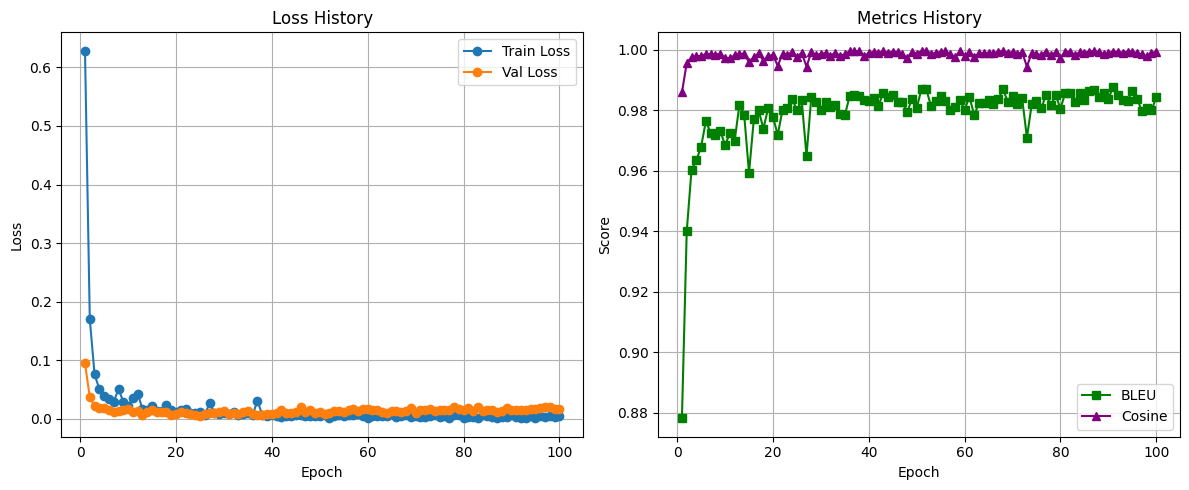


=== SAMPLE RECONSTRUCTIONS (BEST MODEL) ===
Input:  god wisdom hears man old of
Target: old man hears wisdom of god
Pred:   old man hears wisdom of god
------------------------------
Input:  lord upon above throne the the sits
Target: the lord sits upon the throne above
Pred:   the lord sits upon the throne above
------------------------------
Input:  truth feather sees heart (truth/maat) eye
Target: eye sees truth feather (truth/maat) heart
Pred:   eye sees truth feather (truth/maat) heart
------------------------------
Input:  the in the jars sees lord rack
Target: the lord sees the jars in rack
Pred:   the lord sees the jars in rack
------------------------------
Input:  content love life satisfied people peace
Target: people love peace content satisfied life
Pred:   people love peace content satisfied life
------------------------------
Input:  gives youth the milk jar father a
Target: the father gives a milk jar youth
Pred:   the father gives a milk jar youth
--------------------

In [4]:
import torch
import random
import pandas as pd
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from transformers import (
    BartTokenizer, 
    BartForConditionalGeneration, 
    get_linear_schedule_with_warmup
)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. CONFIGURATION & DIRECTORIES
# ==========================================
MODEL_NAME = "facebook/bart-base"
MAX_LEN = 32
BATCH_SIZE = 16
EPOCHS = 100
LEARNING_RATE = 5e-5
SAVE_DIR = "./best_model_checkpoint"

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# ==========================================
# 1. DATA LOADING & PREPARATION
# ==========================================
# Assuming these variables exist in your environment. 
# Added fallbacks for script stability.

# Clean the inputs: Convert multiline strings to space-separated strings
original_shuffled = [s.replace("\n", " ").strip() for s in shuffled_sentences_raw]

# ==========================================
# 2. DATA AUGMENTATION
# ==========================================
print("Generating augmented data...")

def augment_data(ground_truth_list, num_augmentations=10):
    """
    Creates multiple shuffled versions of each ground truth sentence.
    """
    inputs = []
    targets = []
    
    for sentence in ground_truth_list:
        words = sentence.split()
        if len(words) <= 1:
            continue
            
        for _ in range(num_augmentations):
            shuffled_words = words.copy()
            random.shuffle(shuffled_words)
            inputs.append(" ".join(shuffled_words))
            targets.append(sentence)
            
    return inputs, targets

aug_inputs, aug_targets = augment_data(merged_ground_truth_sentences, num_augmentations=10)

all_inputs = aug_inputs + original_shuffled
all_targets = aug_targets + merged_ground_truth_sentences

df = pd.DataFrame({'input_text': all_inputs, 'target_text': all_targets})
print(f"Total dataset size after augmentation: {len(df)}")

# ==========================================
# 3. DATASET & DATALOADER
# ==========================================
class SentenceReconstructionDataset(Dataset):
    def __init__(self, tokenizer, data, max_len=32):
        self.tokenizer = tokenizer
        self.data = data
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        source = str(self.data.iloc[index]['input_text'])
        target = str(self.data.iloc[index]['target_text'])

        source_tok = self.tokenizer(
            source, 
            max_length=self.max_len, 
            padding='max_length', 
            truncation=True, 
            return_tensors='pt'
        )

        target_tok = self.tokenizer(
            target, 
            max_length=self.max_len, 
            padding='max_length', 
            truncation=True, 
            return_tensors='pt'
        )

        # Labels for BART: shift happens internally, but we set -100 for padding
        labels = target_tok['input_ids'].flatten()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids': source_tok['input_ids'].flatten(),
            'attention_mask': source_tok['attention_mask'].flatten(),
            'labels': labels
        }

# ==========================================
# 4. MODEL SETUP
# ==========================================
print(f"Loading {MODEL_NAME} model...")
tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Split Data
train_size = int(0.8 * len(df))
val_size = len(df) - train_size
train_indices, val_indices = random_split(range(len(df)), [train_size, val_size])

train_df = df.iloc[list(train_indices.indices)].reset_index(drop=True)
val_df = df.iloc[list(val_indices.indices)].reset_index(drop=True)

train_set = SentenceReconstructionDataset(tokenizer, train_df, max_len=MAX_LEN)
val_set = SentenceReconstructionDataset(tokenizer, val_df, max_len=MAX_LEN)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

# ==========================================
# 5. METRICS HELPER
# ==========================================
try:
    from sentence_transformers import SentenceTransformer
    sim_model = SentenceTransformer('all-MiniLM-L6-v2')
    calc_cosine = True
except ImportError:
    print("sentence-transformers not installed. Cosine similarity will be skipped.")
    calc_cosine = False

def calculate_metrics(predictions, references):
    chencherry = SmoothingFunction()
    bleu_scores = [sentence_bleu([ref.split()], pred.split(), smoothing_function=chencherry.method1) 
                   for pred, ref in zip(predictions, references)]
    avg_bleu = np.mean(bleu_scores)

    avg_cosine = 0.0
    if calc_cosine:
        pred_embeddings = sim_model.encode(predictions)
        ref_embeddings = sim_model.encode(references)
        cos_sims = cosine_similarity(pred_embeddings, ref_embeddings).diagonal()
        avg_cosine = np.mean(cos_sims)
    
    return avg_bleu, avg_cosine

# ==========================================
# 6. TRAINING LOOP
# ==========================================
history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'bleu': [], 'cosine': []}
best_val_loss = float('inf')

print("Starting training...")

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    total_train_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        total_train_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / len(train_loader)

    # --- VALIDATION ---
    model.eval()
    total_val_loss = 0
    predictions = []
    references = []
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item()
            
            generated_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=MAX_LEN)
            decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            
            # Reset -100 to pad_token_id for proper decoding
            labels_to_decode = labels.clone()
            labels_to_decode[labels_to_decode == -100] = tokenizer.pad_token_id
            decoded_labels = tokenizer.batch_decode(labels_to_decode, skip_special_tokens=True)
            
            predictions.extend(decoded_preds)
            references.extend(decoded_labels)

    avg_val_loss = total_val_loss / len(val_loader)
    bleu, cosine = calculate_metrics(predictions, references)
    
    # --- CHECKPOINTING (BEST VERSION) ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        print(f"--> New best model found! Saving to {SAVE_DIR}...")
        # Using HuggingFace's recommended method instead of legacy torch.save
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
    
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['bleu'].append(bleu)
    history['cosine'].append(cosine)
    
    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | BLEU: {bleu:.4f}")

# ==========================================
# 7. RESULTS & VISUALIZATION
# ==========================================
# Load the best model for final evaluation/visualization
print("Loading best model for final reporting...")
model = BartForConditionalGeneration.from_pretrained(SAVE_DIR).to(device)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['epoch'], history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss History')
plt.xlabel('Epoch'), plt.ylabel('Loss'), plt.legend(), plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['epoch'], history['bleu'], label='BLEU', marker='s', color='green')
if calc_cosine:
    plt.plot(history['epoch'], history['cosine'], label='Cosine', marker='^', color='purple')
plt.title('Metrics History')
plt.xlabel('Epoch'), plt.ylabel('Score'), plt.legend(), plt.grid(True)
plt.tight_layout()
plt.show()

print("\n=== SAMPLE RECONSTRUCTIONS (BEST MODEL) ===")
sample_indices = random.sample(range(len(predictions)), min(10, len(predictions)))
for i in sample_indices:
    print(f"Input:  {val_df.iloc[i]['input_text']}")
    print(f"Target: {references[i]}")
    print(f"Pred:   {predictions[i]}")
    print("-" * 30)

# Save logs
pd.DataFrame(history).to_csv('training_metrics.csv', index=False)
pd.DataFrame({'Input': val_df['input_text'], 'Target': references, 'Prediction': predictions}).to_csv('reconstruction_results.csv', index=False)
print(f"\nTraining complete. Best model saved in: {SAVE_DIR}")